In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

In [2]:
base = Path("../data/")

# Full economic WDI dataset
wdi = pd.read_csv(base / "raw/WDICSV.csv")

# Governance & inequality subset
gov = pd.read_csv(base / "proceed/filtered_indicators.csv")


In [3]:
wdi.columns.tolist()

['Country Name',
 'Country Code',
 'Indicator Name',
 'Indicator Code',
 '1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024']

In [4]:
wdi.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.001597,18.558234,19.043572,19.586457,20.192064,20.828814,21.372164,22.100884,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.096003,7.406706,7.666648,8.020952,8.403358,8.718306,9.097176,9.473374,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.488233,38.779953,39.068462,39.445526,39.818645,40.276374,40.687817,41.211606,NaN,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.668330,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,16.527554,24.627753,25.432092,27.061929,29.154282,31.022083,32.809138,33.783960,35.375216,NaN


2. transform to long format

In [5]:
wdi.columns.tolist()

['Country Name',
 'Country Code',
 'Indicator Name',
 'Indicator Code',
 '1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024']

In [6]:
# --- Economic data (from raw WDI) ---
year_cols = [c for c in wdi.columns if c.isdigit()]
wdi_long = (
    wdi.melt(
        id_vars=["Country Name","Country Code","Indicator Name","Indicator Code"],
        value_vars=year_cols, var_name="year", value_name="value"
    )
    .rename(columns={
        "Country Name":"country",
        "Country Code":"country_code",
        "Indicator Name":"indicator",
        "Indicator Code":"indicator_code"
    })
)
wdi_long["year"] = wdi_long["year"].astype(int)

# --- Governance data (from filtered_indicators.csv) ---
# First check the structure
print("Governance data columns:", gov.columns.tolist()[:10])

# If gov is also in wide format, melt it first
gov_year_cols = [c for c in gov.columns if c.isdigit()]

if gov_year_cols:  # If years are columns (wide format)
    gov_long = (
        gov.melt(
            id_vars=["Country_Name", "Country_Code", "Indicator_Name", "Indicator_Code"],
            value_vars=gov_year_cols, 
            var_name="year", 
            value_name="value"
        )
        .rename(columns={
            "Country_Name":"country",
            "Country_Code":"country_code",
            "Indicator_Name":"indicator",
            "Indicator_Code":"indicator_code"
        })
    )
    gov_long["year"] = gov_long["year"].astype(int)
else:  # If already in long format
    gov_long = gov.rename(columns={
        "Country_Name":"country",
        "Country_Code":"country_code",
        "Indicator_Code":"indicator_code",
        "Indicator_Name":"indicator"
    }, errors="ignore")
    if "year" in gov_long.columns:
        gov_long["year"] = gov_long["year"].astype(int)

print("\nGovernance data shape after transformation:", gov_long.shape)
gov_long.head()

Governance data columns: ['Country_Name', 'Country_Code', 'Indicator_Name', 'Indicator_Code', '1960', '1961', '1962', '1963', '1964', '1965']

Governance data shape after transformation: (4290, 6)


,country,country_code,indicator,indicator_code,year,value
0,Belarus,BLR,Control of Corruption: Estimate,CC.EST,1960,NaN
1,Belarus,BLR,Gini index,SI.POV.GINI,1960,NaN
2,Belarus,BLR,Government Effectiveness: Estimate,GE.EST,1960,NaN
3,Belarus,BLR,Income share held by highest 20%,SI.DST.05TH.20,1960,NaN
4,Belarus,BLR,Income share held by lowest 20%,SI.DST.FRST.20,1960,NaN


# Q1. Did EU accession coincide with a structural shift in GDP-per-capita growth?

- **Purpose:** Test macro divergence linked to 2004/2007 enlargements.  
- **Plot:** *Event-study lines* (year 0 = accession) of GDP growth; group means ±95 % CI.  
- **Method:** **Difference-in-Differences (DiD)** with country and year fixed effects (LSE/OLS)

### What the model means

The model written 

$$
y_{c,t} = \alpha_c + \delta_t + \beta(EU_c \times Post_t) + \gamma X_{c,t} + \varepsilon_{c,t}
$$

can be read in plain language as:

| Term | Meaning |
| -------------------- | -------------------------------------------------------------------------------------------------------------------- |
| $y_{c,t}$ | GDP-growth rate in country *c* at year *t*. |
| $\alpha_c$ | Country fixed effect — controls for stable characteristics of each country (size, culture, geography, institutions). |
| $\delta_t$ | Year fixed effect — controls for global shocks that hit everyone (like 2008 crisis, oil prices). |
| $EU_c$ | 1 if the country eventually joined the EU, 0 otherwise. |
| $Post_t$ | 1 for years **after** the EU enlargement (post-2004 for early joiners), 0 before. |
| $EU_c \times Post_t$ | The "treatment" term — it turns 1 **only for EU members after accession**. |
| $\beta$ | The key coefficient: how much the *average post-2004 change* in GDP growth differed between EU and non-EU groups. |
| $\gamma X_{c,t}$ | Control variables (interest rate, FDI, etc.). |
| $\varepsilon_{c,t}$ | Random noise. |

So, **β** measures the *extra boost (or drop)* in GDP growth that is associated with EU membership *after* joining, beyond what's explained by overall world trends and country-specific baselines.

Select indicators

In [7]:
# Economic indicators
econ_indicators = {
    "GDPpc": "NY.GDP.PCAP.CD",
    "GDP_growth": "NY.GDP.MKTP.KD.ZG",
    "FDI_share": "BX.KLT.DINV.WD.GD.ZS",
    "Unemp": "SL.UEM.TOTL.ZS",
    "LifeExp": "SP.DYN.LE00.IN",
    "Poverty3": "SI.POV.LMIC.GP3",
    "CO2_kt": "EN.ATM.CO2E.KT",
    "RenTFEC": "EG.FEC.RNEW.ZS",
    "NetMig": "SM.POP.NETM"
}

# Governance & inequality indicators
gov_indicators = {
    "Corruption": "CC.EST",
    "GovEffect": "GE.EST",
    "PoliticalStab": "PV.EST",
    "RuleLaw": "RL.EST",
    "RegQuality": "RQ.EST",
    "Gini": "SI.POV.GINI",
    "Top20Share": "SI.DST.FRST.20",
    "Bottom20Share": "SI.DST.05TH.20",
    "Patents": "IP.PAT.RESD"
}


combining datasers

In [8]:
# Filter datasets for specific indicators
wdi_filt = wdi_long.query("indicator_code in @econ_indicators.values()")
gov_filt = gov_long.query("indicator_code in @gov_indicators.values()")  # Changed from gov to gov_long

# Combine datasets
combined = pd.concat([wdi_filt, gov_filt], ignore_index=True)
combined["year"] = combined["year"].astype(int)

print(f"Combined dataset shape: {combined.shape}")
print(f"Unique countries: {combined['country_code'].nunique()}")
print(f"Unique indicators: {combined['indicator_code'].nunique()}")
print(f"Year range: {combined['year'].min()} - {combined['year'].max()}")

combined.head()

Combined dataset shape: (124540, 6)
Unique countries: 266
Unique indicators: 16
Year range: 1960 - 2024


,country,country_code,indicator,indicator_code,year,value
0,Africa Eastern and Southern,AFE,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,1960,NaN
1,Africa Eastern and Southern,AFE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,1960,NaN
2,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,186.121835
3,Africa Eastern and Southern,AFE,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,44.169658
4,Africa Eastern and Southern,AFE,Net migration,SM.POP.NETM,1960,-102704.000000


pivot to country-year panel 

In [9]:
all_indicators = {**econ_indicators, **gov_indicators}
combined["ind_key"] = combined["indicator_code"].map({v:k for k,v in all_indicators.items()})

dfw = (
    combined.pivot_table(
        index=["country_code","country","year"],
        columns="ind_key", values="value", aggfunc="mean"
    )
    .reset_index()
)


In [10]:
EU = ["POL","CZE","SVK"]
NON_EU = ["RUS","UKR","BLR"]

dfw = dfw.query("country_code in @EU or country_code in @NON_EU")
dfw = dfw.query("year >= 1990 and year <= 2024").sort_values(["country_code","year"])

In [11]:
dfw["EU"] = dfw["country_code"].isin(EU).astype(int)
ACCES_YEAR = {"POL":2004,"CZE":2004,"SVK":2004}

dfw["post"] = 0
for c in EU:
    dfw.loc[(dfw["country_code"]==c) & (dfw["year"]>=ACCES_YEAR[c]), "post"] = 1

dfw["treat"] = dfw["EU"] * dfw["post"]


In [12]:
# Ensure outcome and controls are numeric
dfw["GDP_growth"] = pd.to_numeric(dfw["GDP_growth"], errors="coerce")
dfw["FDI_share"] = pd.to_numeric(dfw["FDI_share"], errors="coerce")

# Check if interest_rate exists, if not create placeholder
if "interest_rate" not in dfw.columns:
    print("Note: interest_rate column not found, creating placeholder with NaN values")
    dfw["interest_rate"] = np.nan
else:
    dfw["interest_rate"] = pd.to_numeric(dfw["interest_rate"], errors="coerce")

# Check data before regression
print("\nData summary before regression:")
print(f"Total observations: {len(dfw)}")
print(f"Non-null GDP_growth: {dfw['GDP_growth'].notna().sum()}")
print(f"Non-null FDI_share: {dfw['FDI_share'].notna().sum()}")
print(f"Treatment observations: {dfw['treat'].sum()}")

# DiD formula - exclude interest_rate if all NaN
if dfw["interest_rate"].notna().sum() > 0:
    formula = "GDP_growth ~ treat + FDI_share + interest_rate + C(country_code) + C(year)"
    vars_needed = ["GDP_growth", "treat", "FDI_share", "interest_rate", "country_code", "year"]
else:
    print("Excluding interest_rate from model (all NaN)")
    formula = "GDP_growth ~ treat + FDI_share + C(country_code) + C(year)"
    vars_needed = ["GDP_growth", "treat", "FDI_share", "country_code", "year"]

# Drop rows with missing values in regression variables
dfw_reg = dfw[vars_needed].dropna().copy()
print(f"\nObservations after dropping missing values: {len(dfw_reg)}")
print(f"Countries: {sorted(dfw_reg['country_code'].unique())}")
print(f"Treatment obs in regression sample: {dfw_reg['treat'].sum()}")

# Fit the model with cluster-robust standard errors
mod = smf.ols(formula, data=dfw_reg).fit(
    cov_type="cluster", cov_kwds={"groups": dfw_reg["country_code"]}
)

print("\n" + "="*80)
print("DIFFERENCE-IN-DIFFERENCES RESULTS")
print("="*80)
print(mod.summary())
print("\n" + "="*80)
print(f"DiD estimate (β on treat): {mod.params.get('treat', np.nan):.4f}")
print(f"Standard error: {mod.bse.get('treat', np.nan):.4f}")
print(f"P-value: {mod.pvalues.get('treat', np.nan):.4f}")
print(f"95% CI: [{mod.conf_int().loc['treat', 0]:.4f}, {mod.conf_int().loc['treat', 1]:.4f}]")

Note: interest_rate column not found, creating placeholder with NaN values

Data summary before regression:
Total observations: 210
Non-null GDP_growth: 206
Non-null FDI_share: 198
Treatment observations: 63
Excluding interest_rate from model (all NaN)

Observations after dropping missing values: 197
Countries: ['BLR', 'CZE', 'POL', 'RUS', 'SVK', 'UKR']
Treatment obs in regression sample: 63

DIFFERENCE-IN-DIFFERENCES RESULTS
                            OLS Regression Results                            
Dep. Variable:             GDP_growth   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                 5.187e+13
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           2.58e-34
Time:                        11:09:03   Log-Likelihood:                -549.12
No. Observations:                 197   AIC:                             1180.
Df Residuals:    

/home/master/Documents/competitions/cirsDataSet/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 40, but rank is 6
  warnings.warn('covariance of constraints does not have full '


In [13]:
for col in ["GDP_growth", "FDI_share"]:
    dfw[col] = pd.to_numeric(dfw[col], errors="coerce")

# Decide which controls are usable (have at least 1 non-null)
controls = []
if "FDI_share" in dfw.columns and dfw["FDI_share"].notna().sum() > 0:
    controls.append("FDI_share")
if "interest_rate" in dfw.columns and dfw["interest_rate"].notna().sum() > 0:
    controls.append("interest_rate")

rhs = "treat"
if controls:
    rhs += " + " + " + ".join(controls)
rhs += " + C(country_code) + C(year)"
formula = f"GDP_growth ~ {rhs}"

vars_needed = ["GDP_growth", "treat", "country_code", "year"] + controls
dfw_reg = dfw[vars_needed].dropna().copy()

print(f"Fitting formula: {formula}")
print(f"Observations after dropna: {len(dfw_reg)}")
print(f"Countries in sample: {sorted(dfw_reg['country_code'].unique())}")
print(f"Controls used: {controls}")

if len(dfw_reg) == 0:
    raise ValueError("No rows left after dropna. Check that GDP_growth and controls have data.")

mod = smf.ols(formula, data=dfw_reg).fit(
    cov_type="cluster", cov_kwds={"groups": dfw_reg["country_code"]}
)

print(mod.summary())
print("\nDiD estimate (β on treat):", mod.params.get("treat", np.nan))

Fitting formula: GDP_growth ~ treat + FDI_share + C(country_code) + C(year)
Observations after dropna: 197
Countries in sample: ['BLR', 'CZE', 'POL', 'RUS', 'SVK', 'UKR']
Controls used: ['FDI_share']
                            OLS Regression Results                            
Dep. Variable:             GDP_growth   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                 5.187e+13
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           2.58e-34
Time:                        11:09:03   Log-Likelihood:                -549.12
No. Observations:                 197   AIC:                             1180.
Df Residuals:                     156   BIC:                             1315.
Df Model:                          40                                         
Covariance Type:              cluster                                         
          

/home/master/Documents/competitions/cirsDataSet/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 40, but rank is 6
  warnings.warn('covariance of constraints does not have full '


In [14]:
# Event-study: build event-time dummies and fit ES model (baseline rel_year = -1)
def rel_year(row):
    if row["country_code"] in ACCES_YEAR:
        return row["year"] - ACCES_YEAR[row["country_code"]]
    return np.nan

df_es = dfw.copy()
df_es["rel_year"] = df_es.apply(rel_year, axis=1)

# Keep a reasonable window and use integer bins for clean names
df_es["rel_bin"] = df_es["rel_year"].where(df_es["rel_year"].between(-6, 10))
df_es["rel_bin"] = df_es["rel_bin"].round().astype("Int64")

# ...existing code...
# Create dummies, drop baseline -1, rename to Patsy-safe names, attach and fill NaN with 0
dummies = pd.get_dummies(df_es["rel_bin"], prefix="ry", dtype=int)

# Drop baseline (-1) before renaming
baseline_old = "ry_-1"
if baseline_old in dummies.columns:
    dummies = dummies.drop(columns=[baseline_old])

def safe_dummy_name(col: str) -> str:
    rel = int(col.split("_", 1)[1])
    return f"ry_m{abs(rel)}" if rel < 0 else f"ry_{rel}"

# Rename to safe names and keep a reverse map for plotting order
name_map = {col: safe_dummy_name(col) for col in dummies.columns}
dummies = dummies.rename(columns=name_map)
rel_from_safe = {new: int(old.split("_", 1)[1]) for old, new in name_map.items()}

df_es = pd.concat([df_es, dummies], axis=1)
for c in dummies.columns:
    df_es[c] = df_es[c].fillna(0)

# Choose available controls
controls = []
if "FDI_share" in df_es.columns and df_es["FDI_share"].notna().sum() > 0:
    controls.append("FDI_share")
if "interest_rate" in df_es.columns and df_es["interest_rate"].notna().sum() > 0:
    controls.append("interest_rate")

ry_cols = sorted([c for c in dummies.columns], key=lambda c: rel_from_safe[c])
if not ry_cols:
    raise ValueError("No event-time dummies created. Check rel_year/rel_bin window.")

rhs = " + ".join(ry_cols)
if controls:
    rhs += " + " + " + ".join(controls)
rhs += " + C(country_code) + C(year)"
es_formula = f"GDP_growth ~ {rhs}"

vars_needed = ["GDP_growth", "country_code", "year"] + controls + ry_cols
df_es_reg = df_es[vars_needed].dropna().copy()

print(f"Fitting ES formula: {es_formula}")
print(f"ES observations after dropna: {len(df_es_reg)}")
print(f"ES countries: {sorted(df_es_reg['country_code'].unique())}")
print(f"Controls used in ES: {controls}")
print(f"Event-time terms: {ry_cols}")

es_mod = smf.ols(es_formula, data=df_es_reg).fit(
    cov_type="cluster", cov_kwds={"groups": df_es_reg["country_code"]}
)
print(es_mod.summary())

Fitting ES formula: GDP_growth ~ ry_m6 + ry_m5 + ry_m4 + ry_m3 + ry_m2 + ry_0 + ry_1 + ry_2 + ry_3 + ry_4 + ry_5 + ry_6 + ry_7 + ry_8 + ry_9 + ry_10 + FDI_share + C(country_code) + C(year)
ES observations after dropna: 197
ES countries: ['BLR', 'CZE', 'POL', 'RUS', 'SVK', 'UKR']
Controls used in ES: ['FDI_share']
Event-time terms: ['ry_m6', 'ry_m5', 'ry_m4', 'ry_m3', 'ry_m2', 'ry_0', 'ry_1', 'ry_2', 'ry_3', 'ry_4', 'ry_5', 'ry_6', 'ry_7', 'ry_8', 'ry_9', 'ry_10']
                            OLS Regression Results                            
Dep. Variable:             GDP_growth   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                -5.194e+14
Date:                Tue, 21 Oct 2025   Prob (F-statistic):               1.00
Time:                        11:09:03   Log-Likelihood:                -526.91
No. Observations:                 197   AIC:              

/home/master/Documents/competitions/cirsDataSet/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 55, but rank is 6
  warnings.warn('covariance of constraints does not have full '


In [25]:
import re

def parse_rel_safe(name: str) -> float:
    """Parse relative-year dummy name like ry_-2.0 → -2."""
    m = re.search(r"ry_(-?\d+(\.\d+)?)", name)
    return float(m.group(1)) if m else np.nan

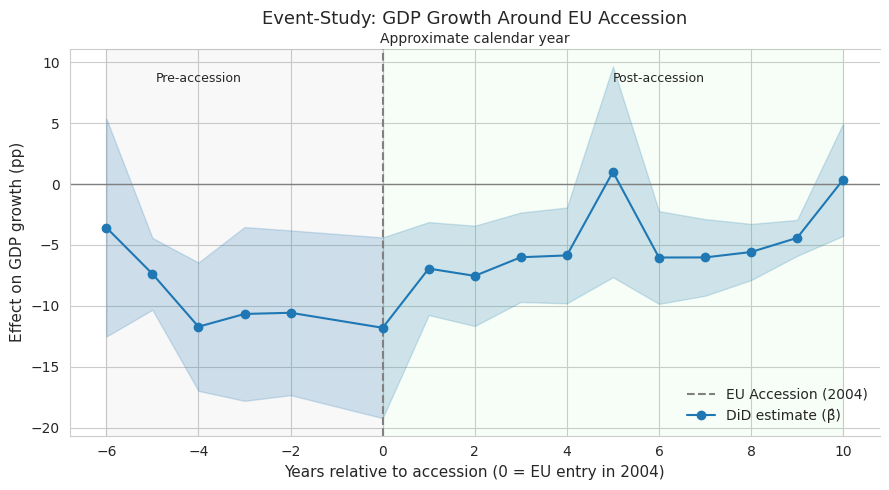

In [30]:
coef = es_mod.params.filter(regex=r"^ry_")
se   = es_mod.bse.filter(regex=r"^ry_")

def parse_rel_safe(name: str) -> int:
    tag = name.split("_", 1)[1]
    return -int(tag[1:]) if tag.startswith("m") else int(tag)

es_df = (
    pd.DataFrame({"term": coef.index, "beta": coef.values, "se": se.reindex(coef.index).values})
    .assign(rel=lambda d: d["term"].map(parse_rel_safe))
    .sort_values("rel")
)

if es_df.empty:
    raise ValueError("No ES coefficients found to plot.")

# === Customization parameters ===
ACCESSION_YEAR = 2004  # main accession wave for POL/CZE/SVK
x = es_df["rel"]
y = es_df["beta"]
err = 1.96 * es_df["se"]

fig, ax = plt.subplots(figsize=(9,5))

# Horizontal baseline (no effect)
ax.axhline(0, color="gray", lw=1)

# Vertical dashed line at accession
ax.axvline(0, color="gray", lw=1.5, ls="--", label=f"EU Accession ({ACCESSION_YEAR})")

# Confidence intervals as shaded band
ax.fill_between(x, y - err, y + err, color="tab:blue", alpha=0.2)

# Points and line
ax.plot(x, y, "o-", color="tab:blue", lw=1.5, label="DiD estimate (β̂)")

# Titles and labels
ax.set_title("Event-Study: GDP Growth Around EU Accession", fontsize=13)
ax.set_xlabel("Years relative to accession (0 = EU entry in 2004)", fontsize=11)
ax.set_ylabel("Effect on GDP growth (pp)", fontsize=11)

# Secondary x-axis for approximate calendar years
years = x + ACCESSION_YEAR
secax = ax.secondary_xaxis('top', functions=(lambda r: r + ACCESSION_YEAR, lambda y: y - ACCESSION_YEAR))
secax.set_xlabel("Approximate calendar year", fontsize=10)
secax.set_xticks([-6, -3, 0, 3, 6, 9])
secax.set_xticklabels([ACCESSION_YEAR-6, ACCESSION_YEAR-3, ACCESSION_YEAR, ACCESSION_YEAR+3, ACCESSION_YEAR+6, ACCESSION_YEAR+9])

# Add region shading (optional)
ax.axvspan(-6, 0, color="gray", alpha=0.05)
ax.axvspan(0, 10, color="lightgreen", alpha=0.07)
ax.text(-4, max(y+err)*0.9, "Pre-accession", ha="center", va="center", fontsize=9)
ax.text(6, max(y+err)*0.9, "Post-accession", ha="center", va="center", fontsize=9)

ax.legend(frameon=False, loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()




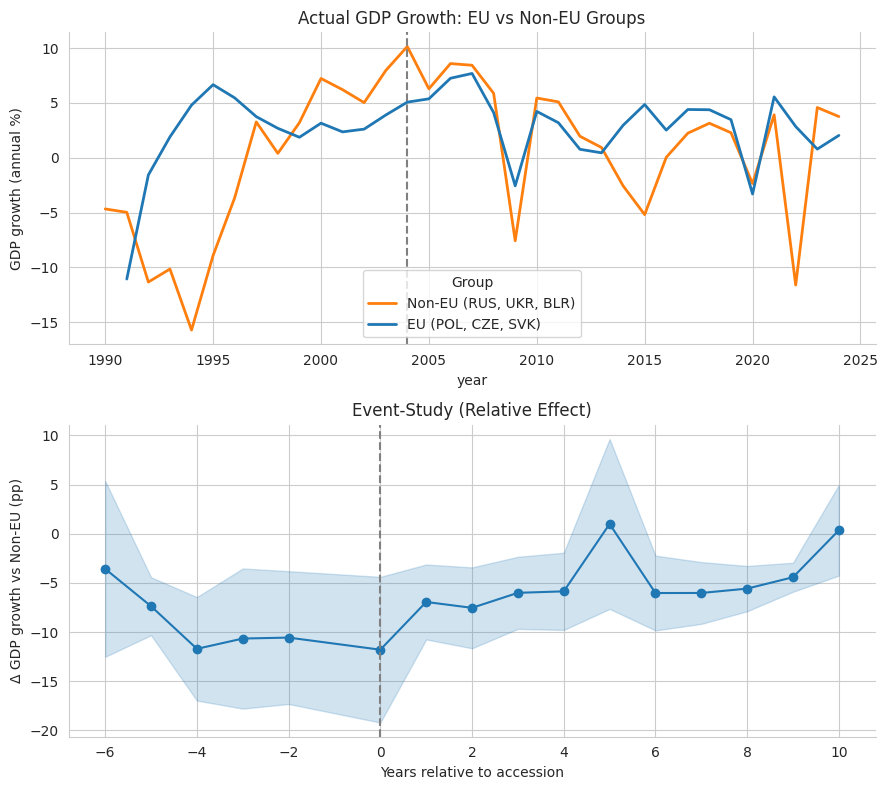

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(9,8), sharex=False)

# (a) Actual GDP growth
# Create a temporary column for clearer legend labels
dfw['Group'] = dfw['EU'].map({0: 'Non-EU (RUS, UKR, BLR)', 1: 'EU (POL, CZE, SVK)'})
palette = {'Non-EU (RUS, UKR, BLR)': "tab:orange", 'EU (POL, CZE, SVK)': "tab:blue"}

# Plot group averages
sns.lineplot(
    ax=axes[0],
    data=dfw,
    x="year",
    y="GDP_growth",
    hue="Group",
    palette=palette,
    lw=2,
    errorbar=None  # Use errorbar=None for clean lines of the mean
)
axes[0].axvline(2004, color="gray", ls="--")
axes[0].set_title("Actual GDP Growth: EU vs Non-EU Groups")
axes[0].set_ylabel("GDP growth (annual %)")
axes[0].legend(title="Group")

# (b) Event-study
axes[1].fill_between(x, y - err, y + err, color="tab:blue", alpha=0.2)
axes[1].plot(x, y, "o-", color="tab:blue", lw=1.5)
axes[1].axvline(0, color="gray", ls="--")
axes[1].set_title("Event-Study (Relative Effect)")
axes[1].set_xlabel("Years relative to accession")
axes[1].set_ylabel("Δ GDP growth vs Non-EU (pp)")

sns.despine()
plt.tight_layout()
plt.show()




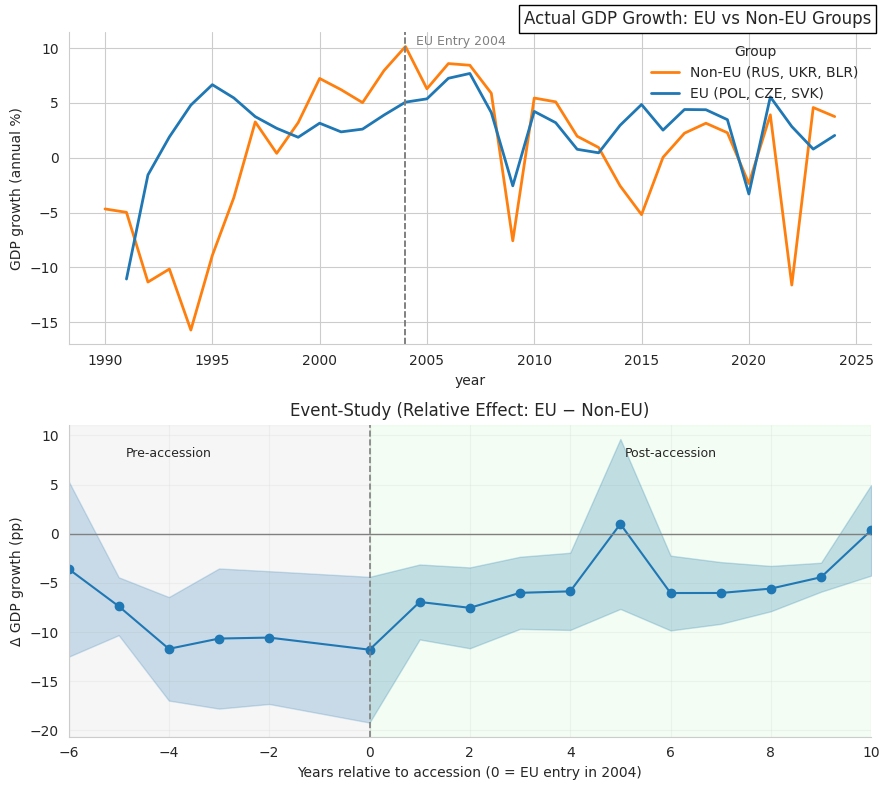

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(9,8), sharex=False)

# === (a) Actual GDP growth ===
dfw['Group'] = dfw['EU'].map({0: 'Non-EU (RUS, UKR, BLR)', 1: 'EU (POL, CZE, SVK)'})
palette = {'Non-EU (RUS, UKR, BLR)': "tab:orange", 'EU (POL, CZE, SVK)': "tab:blue"}

sns.lineplot(
    ax=axes[0],
    data=dfw,
    x="year",
    y="GDP_growth",
    hue="Group",
    palette=palette,
    lw=2,
    errorbar=None
)
axes[0].axvline(2004, color="gray", ls="--", lw=1.2)
axes[0].set_title(
    "Actual GDP Growth: EU vs Non-EU Groups", 
    fontsize=12, 
    loc='right', 
    bbox=dict(boxstyle='square,pad=0.3', edgecolor='black', facecolor='white')
)
axes[0].set_ylabel("GDP growth (annual %)")
axes[0].legend(title="Group", frameon=False, loc="upper right")
axes[0].text(2004.5, axes[0].get_ylim()[1]*0.9, "EU Entry 2004", fontsize=9, color="gray")

# === (b) Event-study ===
axes[1].fill_between(x, y - err, y + err, color="tab:blue", alpha=0.25)
axes[1].plot(x, y, "o-", color="tab:blue", lw=1.5)
axes[1].axhline(0, color="gray", lw=1)
axes[1].axvline(0, color="gray", ls="--", lw=1.2)

# add pre/post shaded bands
axes[1].axvspan(-6, 0, color="lightgray", alpha=0.2)
axes[1].axvspan(0, 10, color="lightgreen", alpha=0.1)

# concise region labels
axes[1].text(-4, max(y+err)*0.85, "Pre-accession", ha="center", va="center", fontsize=9)
axes[1].text(6, max(y+err)*0.85, "Post-accession", ha="center", va="center", fontsize=9)

axes[1].set_title("Event-Study (Relative Effect: EU − Non-EU)", fontsize=12)
axes[1].set_xlabel("Years relative to accession (0 = EU entry in 2004)")
axes[1].set_ylabel("Δ GDP growth (pp)")
axes[1].set_xlim(-6, 10)
axes[1].grid(alpha=0.2)

sns.despine()
plt.tight_layout()
plt.show()


In [18]:
dfw["Post"] = dfw["post"]

# Drop rows with missing values for the regression variables
fdi_reg_df = dfw[["GDP_growth", "FDI_share", "Post", "country_code", "year"]].dropna()

fdi_formula = "GDP_growth ~ FDI_share*Post + C(country_code) + C(year)"
fdi_mod = smf.ols(fdi_formula, data=fdi_reg_df).fit(
    cov_type="cluster", cov_kwds={"groups": fdi_reg_df["country_code"]}
)
fdi_mod.summary()

/home/master/Documents/competitions/cirsDataSet/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 41, but rank is 6
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             GDP_growth   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                 1.249e+13
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           9.05e-33
Time:                        11:11:53   Log-Likelihood:                -548.98
No. Observations:                 197   AIC:                             1182.
Df Residuals:                     155   BIC:                             1320.
Df Model:                          41                                         
Covariance Type:              cluster                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                -10.5269      0.586    -17.970      0.000     -11.675      -9.379
C(country_code)[T.CZE]     1.5639      0.854      1.832      0.067      -0.109       3.237
C(country_code)[T.POL]     3.4927      0.676      5.166      0.000       2.168       4.818
C(country_code)[T.RUS]    -1.1432      0.165     -6.930      0.000      -1.467      -0.820
C(country_code)[T.SVK]     2.6900      0.671      4.010      0.000       1.375       4.005
C(country_code)[T.UKR]    -3.9468      0.215    -18.396      0.000      -4.367      -3.526
C(year)[T.1992]            3.0297      2.594      1.168      0.243      -2.055       8.114
C(year)[T.1993]            5.9084      2.157      2.740      0.006       1.681      10.135
C(year)[T.1994]            4.5747      4.436      1.031      0.302      -4.119      13.269
C(year)[T.1995]            8.8782      3.298      2.692      0.007       2.414      15.343
C(year)[T.1996]           10.9093      2.027      5.381      0.000       6.936      14.883
C(year)[T.1997]           13.4947      2.128      6.340      0.000       9.323      17.666
C(year)[T.1998]           11.4857      1.679      6.839      0.000       8.194      14.777
C(year)[T.1999]           12.4176      2.241      5.541      0.000       8.025      16.810
C(year)[T.2000]           15.0514      2.791      5.392      0.000       9.581      20.522
C(year)[T.2001]           14.1856      2.450      5.789      0.000       9.383      18.988
C(year)[T.2002]           13.6428      2.337      5.839      0.000       9.063      18.223
C(year)[T.2003]           15.8972      2.272      6.997      0.000      11.444      20.350
C(year)[T.2004]           19.3097      1.728     11.178      0.000      15.924      22.696
C(year)[T.2005]           17.5192      2.367      7.402      0.000      12.880      22.158
C(year)[T.2006]           19.6044      1.770     11.074      0.000      16.135      23.074
C(year)[T.2007]           19.7011      2.130      9.251      0.000      15.527      23.875
C(year)[T.2008]           16.4855      1.919      8.592      0.000      12.725      20.246
C(year)[T.2009]            6.3678      2.733      2.330      0.020       1.011      11.725
C(year)[T.2010]           16.3578      1.589     10.294      0.000      13.243      19.472
C(year)[T.2011]           15.6313      1.275     12.263      0.000      13.133      18.130
C(year)[T.2012]           12.8286      1.767      7.259      0.000       9.365      16.292
C(year)[T.2013]           12.0936      1.389      8.709      0.000       9.372      14.815
C(year)[T.2014]           11.6932      2.579      4.535      0.000       6.639      16.747
C(year)[T.2015]           11.3062      3.019      3.744      0.000       5.388      17.224
C(year)[T.2016]           12.8748      1.725      7.465      0.000       9.494  

/tmp/ipykernel_13451/2170584068.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  w = dfw.groupby("country_code").apply(


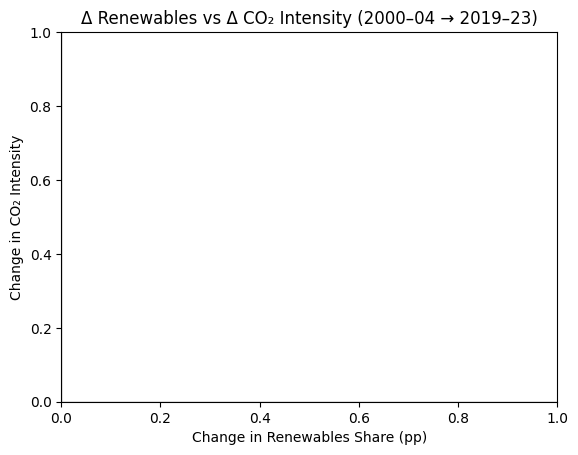

In [20]:
w = dfw.groupby("country_code").apply(
    lambda g: pd.Series({
        "Renew_00_04": g.query("year.between(2000,2004)")["RenTFEC"].mean() if "RenTFEC" in g else np.nan,
        "Renew_19_23": g.query("year.between(2019,2023)")["RenTFEC"].mean() if "RenTFEC" in g else np.nan,
        "CO2_00_04": g.query("year.between(2000,2004)")["CO2_kt"].mean() if "CO2_kt" in g else np.nan,
        "CO2_19_23": g.query("year.between(2019,2023)")["CO2_kt"].mean() if "CO2_kt" in g else np.nan,
        "GDPpc_00_04": g.query("year.between(2000,2004)")["GDPpc"].mean() if "GDPpc" in g else np.nan,
        "GDPpc_19_23": g.query("year.between(2019,2023)")["GDPpc"].mean() if "GDPpc" in g else np.nan,
        "country": g["country"].iloc[0],
        "EU": g["EU"].iloc[0]
    })
).reset_index()

w["dRenew"] = w["Renew_19_23"] - w["Renew_00_04"]
w["CO2_int_00_04"] = w["CO2_00_04"] / (w["GDPpc_00_04"]+1e-9)
w["CO2_int_19_23"] = w["CO2_19_23"] / (w["GDPpc_19_23"]+1e-9)
w["dCO2_int"] = w["CO2_int_19_23"] - w["CO2_int_00_04"]

sns.scatterplot(data=w, x="dRenew", y="dCO2_int", hue="EU", s=80)
plt.axvline(0,color="gray",lw=1); plt.axhline(0,color="gray",lw=1)
plt.title("Δ Renewables vs Δ CO₂ Intensity (2000–04 → 2019–23)")
plt.xlabel("Change in Renewables Share (pp)")
plt.ylabel("Change in CO₂ Intensity")
plt.show()


In [21]:
w

,country_code,Renew_00_04,Renew_19_23,CO2_00_04,CO2_19_23,GDPpc_00_04,GDPpc_19_23,country,EU,dRenew,CO2_int_00_04,CO2_int_19_23,dCO2_int
0,BLR,6.20,8.133333,NaN,NaN,1639.579553,7352.350017,Belarus,0,1.933333,NaN,NaN,NaN
1,CZE,6.66,16.700000,NaN,NaN,8493.653622,27021.070599,Czechia,1,10.040000,NaN,NaN,NaN
2,POL,7.26,15.633333,NaN,NaN,5438.374302,18339.487575,Poland,1,8.373333,NaN,NaN,NaN
3,RUS,3.48,3.466667,NaN,NaN,2665.392798,12752.011914,Russian Federation,0,-0.013333,NaN,NaN,NaN
4,SVK,5.34,17.700000,NaN,NaN,7402.855260,21456.428500,Slovak Republic,1,12.360000,NaN,NaN,NaN
5,UKR,1.12,8.333333,NaN,NaN,966.859314,4288.969141,Ukraine,0,7.213333,NaN,NaN,NaN


In [24]:
def winsorize(s, p=0.01):
    lo, hi = s.quantile([p,1-p])
    return s.clip(lo, hi)

dfw_rb = dfw[~((dfw["country_code"]=="UKR") &
               (dfw["year"].isin([2014,2015,2022,2023])))]

# Define variables needed for the simple DiD model
# 'controls' and 'formula' are correctly defined in a previous cell for this model
vars_needed_robust = ["GDP_growth", "treat", "country_code", "year"] + controls
dfw_rb_reg = dfw_rb[vars_needed_robust].dropna()

robust_mod = smf.ols(formula, data=dfw_rb_reg).fit(
    cov_type="cluster", cov_kwds={"groups": dfw_rb_reg["country_code"]}
)
print("Robust β_treat:", robust_mod.params.get("treat"))

Robust β_treat: -4.357186533278061
